<a href="https://colab.research.google.com/github/RANGAM-AKHILA/project/blob/main/speaker_identification_hubert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q scikit-learn tqdm joblib

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [ ]:
import pandas as pd

full_train_df = pd.read_csv(
    "/content/drive/MyDrive/IASNLP/hubert_features/train_metadata.csv"
)

print(full_train_df.shape)
full_train_df.head()

(6000, 4)


,utt_id,speaker_id,dialect,language
0,IISc_RESPIN_te_D1_92205_522001_M_BANK_900214_9...,92205,D1,te
1,IISc_RESPIN_te_D1_90010_522615_F_BANK_902408_9...,90010,D1,te
2,IISc_RESPIN_te_D1_90012_524131_M_BANK_902269_9...,90012,D1,te
3,IISc_RESPIN_te_D1_90875_522002_M_AGRI_902888_9...,90875,D1,te
4,IISc_RESPIN_te_D1_90052_522001_F_BANK_900087_9...,90052,D1,te


In [ ]:
speaker_counts = (
    full_train_df["speaker_id"]
    .value_counts()
)

valid_speakers = speaker_counts[
    speaker_counts >= 2
].index

filtered_df = full_train_df[
    full_train_df["speaker_id"]
    .isin(valid_speakers)
].reset_index(drop=True)

print("Filtered Samples:", len(filtered_df))
print("Remaining Speakers:", filtered_df["speaker_id"].nunique())

Filtered Samples: 5721
Remaining Speakers: 1020


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

filtered_df["label"] = le.fit_transform(
    filtered_df["speaker_id"]
)

print(
    "Number of Speakers:",
    len(le.classes_)
)

Number of Speakers: 1020


In [ ]:
RESULT_CSV = "/content/drive/MyDrive/IASNLP/hubert_features/hubert_speaker_results.csv"

if os.path.exists(RESULT_CSV):

    results_df = pd.read_csv(
        RESULT_CSV
    )

    completed_layers = set(
        results_df["Layer"].tolist()
    )

    print(
        f"Found {len(completed_layers)} completed layers"
    )

else:

    results_df = pd.DataFrame(
        columns=["Layer", "Accuracy"]
    )

    completed_layers = set()

print("Completed Layers:", completed_layers)

Found 2 completed layers
Completed Layers: {0, 1}


In [ ]:
if os.path.exists(RESULT_CSV):

    results_df = pd.read_csv(
        RESULT_CSV
    )

    completed_layers = set(
        results_df["Layer"].tolist()
    )

    print(
        f"Found {len(completed_layers)} completed layers"
    )

else:

    results_df = pd.DataFrame(
        columns=["Layer", "Accuracy"]
    )

    completed_layers = set()

print("Completed Layers:", completed_layers)

Found 2 completed layers
Completed Layers: {0, 1}


Layer 0 already completed. Skipping...
Layer 1 already completed. Skipping...

PROCESSING LAYER 2


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 2 Accuracy: 74.76%
Checkpoint Saved -> Layer 2
Results CSV Updated

PROCESSING LAYER 3


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 3 Accuracy: 75.90%
Checkpoint Saved -> Layer 3
Results CSV Updated

PROCESSING LAYER 4


...

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 10 Accuracy: 55.63%
Checkpoint Saved -> Layer 10
Results CSV Updated

PROCESSING LAYER 11


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 11 Accuracy: 64.19%
Checkpoint Saved -> Layer 11
Results CSV Updated

PROCESSING LAYER 12


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 12 Accuracy: 59.56%
Checkpoint Saved -> Layer 12
Results CSV Updated


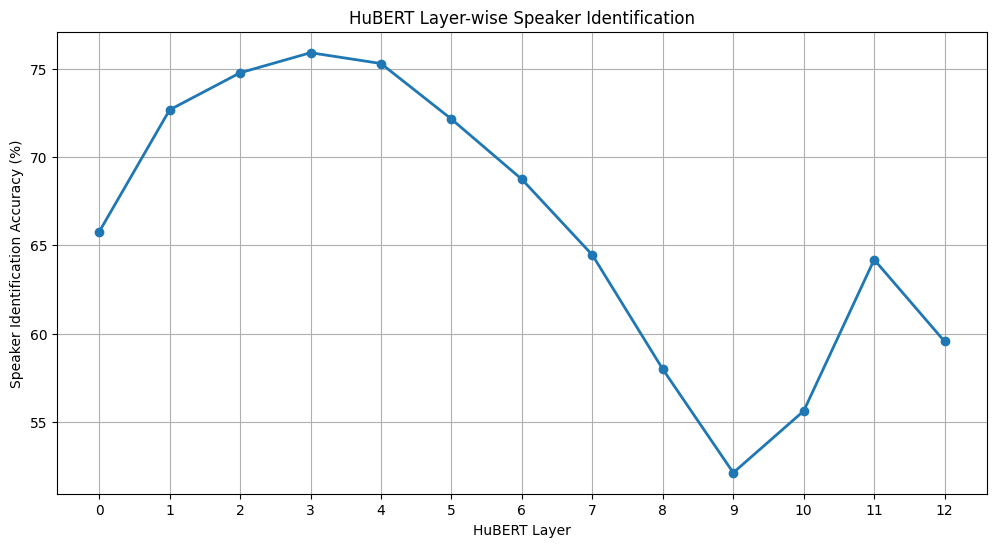

In [ ]:
from sklearn.model_selection import train_test_split

layer_accuracies = []

# Define BASE_DIR
BASE_DIR = "/content/drive/MyDrive/IASNLP/hubert_features/"

# Define CHECKPOINT_DIR here, assuming BASE_DIR is already defined
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for LAYER in range(13):

    if LAYER in completed_layers:

        print(
            f"Layer {LAYER} already completed. Skipping..."
        )

        continue

    print("\n" + "="*60)
    print(f"PROCESSING LAYER {LAYER}")
    print("="*60)

    FEATURE_DIR = os.path.join(
        BASE_DIR,
        f"train/layer_{LAYER}"
    )

    X = []
    y = []

    for _, row in tqdm(
        filtered_df.iterrows(),
        total=len(filtered_df)
    ):

        feature_path = os.path.join(
            FEATURE_DIR,
            f"{row['utt_id']}.npy"
        )

        if not os.path.exists(feature_path):
            continue

        feat = np.load(
            feature_path
        )

        if feat.ndim > 1:
            feat = feat.mean(axis=0)

        X.append(feat)
        y.append(row["label"])

    X = np.array(X)
    y = np.array(y)

    print("Loaded Samples :", len(X))
    print("Feature Shape  :", X.shape)

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_val = scaler.transform(
        X_val
    )

    clf = LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=42
    )

    clf.fit(
        X_train,
        y_train
    )

    preds = clf.predict(
        X_val
    )

    acc = (
        accuracy_score(
            y_val,
            preds
        ) * 100
    )

    print(
        f"Layer {LAYER} Accuracy: {acc:.2f}%"
    )

    model_path = os.path.join(
        CHECKPOINT_DIR,
        f"layer_{LAYER}_model.pkl"
    )

    scaler_path = os.path.join(
        CHECKPOINT_DIR,
        f"layer_{LAYER}_scaler.pkl"
    )

    joblib.dump(
        clf,
        model_path
    )

    joblib.dump(
        scaler,
        scaler_path
    )

    print(
        f"Checkpoint Saved -> Layer {LAYER}"
    )

    new_row = pd.DataFrame({
        "Layer": [LAYER],
        "Accuracy": [acc]
    })

    results_df = pd.concat(
        [results_df, new_row],
        ignore_index=True
    )

    results_df.to_csv(
        RESULT_CSV,
        index=False
    )

    print(
        "Results CSV Updated"
    )

# =====================================================
# PLOT RESULTS AFTER ALL LAYERS ARE PROCESSED
# =====================================================
import matplotlib.pyplot as plt

results_df = pd.read_csv(
    RESULT_CSV
)

results_df = results_df.sort_values(
    "Layer"
)

plt.figure(figsize=(12,6))

plt.plot(
    results_df["Layer"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(range(13))

plt.xlabel(
    "HuBERT Layer"
)

plt.ylabel(
    "Speaker Identification Accuracy (%)"
)

plt.title(
    "HuBERT Layer-wise Speaker Identification"
)

plt.grid(True)

plt.savefig(
    os.path.join(
        BASE_DIR,
        "speaker_layerwise_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

wavlm speaker identification


In [ ]:
import pandas as pd

full_train_df = pd.read_csv(
    "/content/drive/MyDrive/IASNLP/Wavlm_features/train_metadata.csv"
)

print(full_train_df.shape)
full_train_df.head()

(6000, 4)


,utt_id,speaker_id,dialect,language
0,IISc_RESPIN_te_D1_92205_522001_M_BANK_900214_9...,92205,D1,te
1,IISc_RESPIN_te_D1_90010_522615_F_BANK_902408_9...,90010,D1,te
2,IISc_RESPIN_te_D1_90012_524131_M_BANK_902269_9...,90012,D1,te
3,IISc_RESPIN_te_D1_90875_522002_M_AGRI_902888_9...,90875,D1,te
4,IISc_RESPIN_te_D1_90052_522001_F_BANK_900087_9...,90052,D1,te


In [ ]:
speaker_counts = (
    full_train_df["speaker_id"]
    .value_counts()
)

valid_speakers = speaker_counts[
    speaker_counts >= 2
].index

filtered_df = full_train_df[
    full_train_df["speaker_id"]
    .isin(valid_speakers)
].reset_index(drop=True)

print("Filtered Samples:", len(filtered_df))
print("Remaining Speakers:", filtered_df["speaker_id"].nunique())

Filtered Samples: 5721
Remaining Speakers: 1020


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

filtered_df["label"] = le.fit_transform(
    filtered_df["speaker_id"]
)

print(
    "Number of Speakers:",
    len(le.classes_)
)

Number of Speakers: 1020


In [ ]:
RESULT_CSV = "/content/drive/MyDrive/IASNLP/Wavlm_features/wavlm_speaker_results.csv"

if os.path.exists(RESULT_CSV):

    results_df = pd.read_csv(
        RESULT_CSV
    )

    completed_layers = set(
        results_df["Layer"].tolist()
    )

    print(
        f"Found {len(completed_layers)} completed layers"
    )

else:

    results_df = pd.DataFrame(
        columns=["Layer", "Accuracy"]
    )

    completed_layers = set()

print("Completed Layers:", completed_layers)

Found 8 completed layers
Completed Layers: {0, 1, 2, 3, 4, 5, 6, 7}


In [ ]:
if os.path.exists(RESULT_CSV):

    results_df = pd.read_csv(
        RESULT_CSV
    )

    completed_layers = set(
        results_df["Layer"].tolist()
    )

    print(
        f"Found {len(completed_layers)} completed layers"
    )

else:

    results_df = pd.DataFrame(
        columns=["Layer", "Accuracy"]
    )

    completed_layers = set()

print("Completed Layers:", completed_layers)

Found 8 completed layers
Completed Layers: {0, 1, 2, 3, 4, 5, 6, 7}


Layer 0 already completed. Skipping...
Layer 1 already completed. Skipping...
Layer 2 already completed. Skipping...
Layer 3 already completed. Skipping...
Layer 4 already completed. Skipping...
Layer 5 already completed. Skipping...
Layer 6 already completed. Skipping...
Layer 7 already completed. Skipping...

PROCESSING LAYER 8


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 8 Accuracy: 44.63%
Checkpoint Saved -> Layer 8
Results CSV Updated

PROCESSING LAYER 9


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 9 Accuracy: 40.70%
Checkpoint Saved -> Layer 9
Results CSV Updated

PROCESSING LAYER 10


...

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 10 Accuracy: 41.83%
Checkpoint Saved -> Layer 10
Results CSV Updated

PROCESSING LAYER 11


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 11 Accuracy: 45.15%
Checkpoint Saved -> Layer 11
Results CSV Updated

PROCESSING LAYER 12


  0%|          | 0/5721 [00:00<?, ?it/s]

Loaded Samples : 5721
Feature Shape  : (5721, 768)
Layer 12 Accuracy: 42.71%
Checkpoint Saved -> Layer 12
Results CSV Updated


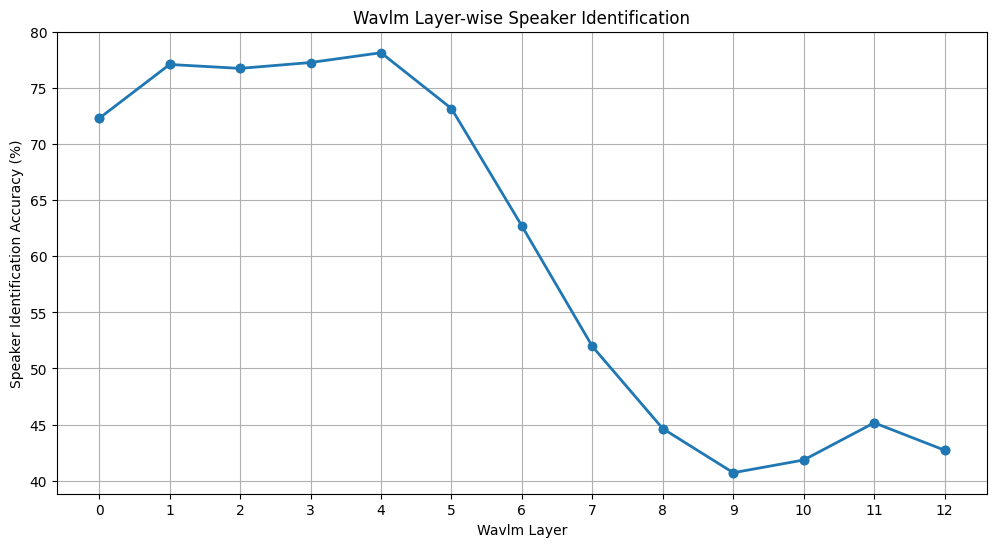

In [ ]:
from sklearn.model_selection import train_test_split

layer_accuracies = []

# Define BASE_DIR
BASE_DIR = "/content/drive/MyDrive/IASNLP/Wavlm_features"

# Define CHECKPOINT_DIR here, assuming BASE_DIR is already defined
CHECKPOINT_DIR = os.path.join(BASE_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

for LAYER in range(13):

    if LAYER in completed_layers:

        print(
            f"Layer {LAYER} already completed. Skipping..."
        )

        continue

    print("\n" + "="*60)
    print(f"PROCESSING LAYER {LAYER}")
    print("="*60)

    FEATURE_DIR = os.path.join(
        BASE_DIR,
        f"train/layer_{LAYER}"
    )

    X = []
    y = []

    for _, row in tqdm(
        filtered_df.iterrows(),
        total=len(filtered_df)
    ):

        feature_path = os.path.join(
            FEATURE_DIR,
            f"{row['utt_id']}.npy"
        )

        if not os.path.exists(feature_path):
            continue

        feat = np.load(
            feature_path
        )

        if feat.ndim > 1:
            feat = feat.mean(axis=0)

        X.append(feat)
        y.append(row["label"])

    X = np.array(X)
    y = np.array(y)

    print("Loaded Samples :", len(X))
    print("Feature Shape  :", X.shape)

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_val = scaler.transform(
        X_val
    )

    clf = LogisticRegression(
        max_iter=3000,
        solver="lbfgs",
        n_jobs=-1,
        random_state=42
    )

    clf.fit(
        X_train,
        y_train
    )

    preds = clf.predict(
        X_val
    )

    acc = (
        accuracy_score(
            y_val,
            preds
        ) * 100
    )

    print(
        f"Layer {LAYER} Accuracy: {acc:.2f}%"
    )

    model_path = os.path.join(
        CHECKPOINT_DIR,
        f"layer_{LAYER}_model.pkl"
    )

    scaler_path = os.path.join(
        CHECKPOINT_DIR,
        f"layer_{LAYER}_scaler.pkl"
    )

    joblib.dump(
        clf,
        model_path
    )

    joblib.dump(
        scaler,
        scaler_path
    )

    print(
        f"Checkpoint Saved -> Layer {LAYER}"
    )

    new_row = pd.DataFrame({
        "Layer": [LAYER],
        "Accuracy": [acc]
    })

    results_df = pd.concat(
        [results_df, new_row],
        ignore_index=True
    )

    results_df.to_csv(
        RESULT_CSV,
        index=False
    )

    print(
        "Results CSV Updated"
    )

# =====================================================
# PLOT RESULTS AFTER ALL LAYERS ARE PROCESSED
# =====================================================
import matplotlib.pyplot as plt

results_df = pd.read_csv(
    RESULT_CSV
)

results_df = results_df.sort_values(
    "Layer"
)

plt.figure(figsize=(12,6))

plt.plot(
    results_df["Layer"],
    results_df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(range(13))

plt.xlabel(
    "Wavlm Layer"
)

plt.ylabel(
    "Speaker Identification Accuracy (%)"
)

plt.title(
    "Wavlm Layer-wise Speaker Identification"
)

plt.grid(True)

plt.savefig(
    os.path.join(
        BASE_DIR,
        "speaker_layerwise_accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()